aula-o5

Tabela de cores: https://www.homehost.com.br/blog/tutoriais/tabela-de-cores-html/



aula-05


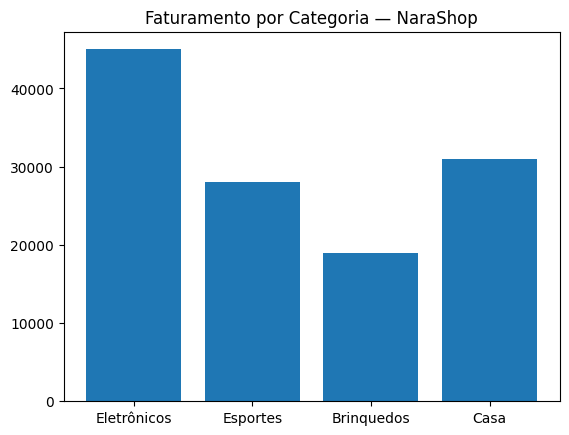

In [23]:
print('aula-05')
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

categorias = ['Eletrônicos', 'Esportes', 'Brinquedos', 'Casa']
valores = [45000, 28000, 19000, 31000]
plt.bar(categorias, valores)
plt.title('Faturamento por Categoria — NaraShop')
plt.show()


In [24]:
url = 'pedidos_narashop.csv'
df = pd.read_csv(url, encoding='utf-8', sep=';')
df.head()

,pedido_id,vendedor,categoria,produto,status_pedido,quantidade,valor_unitario,prazo_entrega_dias
0,10001,Rafael Oliveira,Esportes,Raquete de Beach Tennis,Entregue,5,98.01,12
1,10002,Leandro Reis,Eletrônicos,SSD Externo,Entregue,4,599.89,8
2,10003,Flávia Azevedo,Eletrônicos,Notebook,Entregue,5,3774.96,5
3,10004,Lucas Ribeiro,Esportes,Garrafa Térmica,Entregue,1,87.67,4
4,10005,Vinícius Lopes,Eletrônicos,SSD Externo,Entregue,3,439.02,3


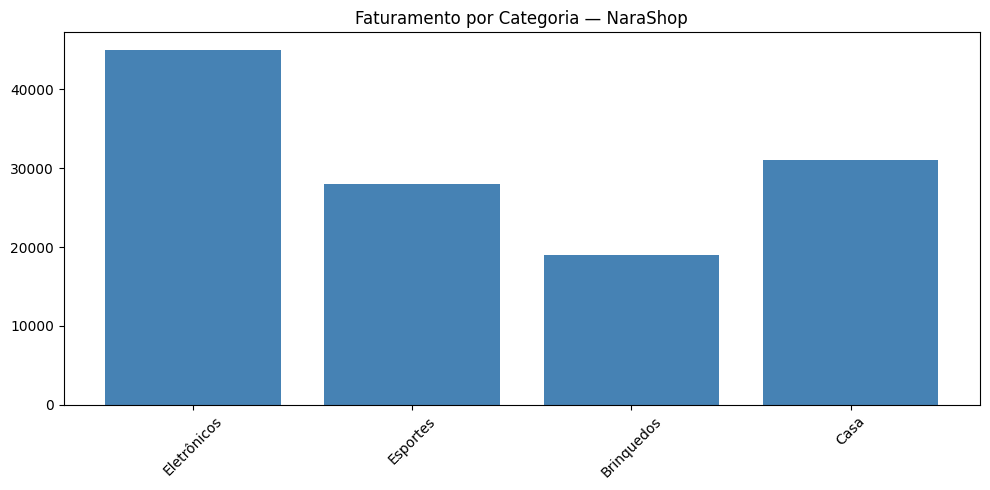

In [25]:
plt.figure(figsize=(10, 5)) # largura x altura em polegadas
plt.bar(categorias, valores, color='steelblue')
plt.title('Faturamento por Categoria — NaraShop')
plt.xticks(rotation=45) # rótulos inclinados
plt.tight_layout() # evita corte
plt.show()

In [28]:
df['valor_pedido'] = df['quantidade'] * df['valor_unitario']
df

,pedido_id,vendedor,categoria,produto,status_pedido,quantidade,valor_unitario,prazo_entrega_dias,valor_pedido
0,10001,Rafael Oliveira,Esportes,Raquete de Beach Tennis,Entregue,5,98.01,12,490.05
1,10002,Leandro Reis,Eletrônicos,SSD Externo,Entregue,4,599.89,8,2399.56
2,10003,Flávia Azevedo,Eletrônicos,Notebook,Entregue,5,3774.96,5,18874.80
3,10004,Lucas Ribeiro,Esportes,Garrafa Térmica,Entregue,1,87.67,4,87.67
4,10005,Vinícius Lopes,Eletrônicos,SSD Externo,Entregue,3,439.02,3,1317.06
...,...,...,...,...,...,...,...,...,...
19995,29996,Tatiane Cunha,Esportes,Raquete de Beach Tennis,Entregue,4,178.86,5,715.44
19996,29997,Ana Lima,Casa e Decoração,Tapete Sala,Em trânsito,4,166.27,5,665.08
19997,29998,Patrícia Rocha,Eletrônicos,Tablet,Cancelado,5,1577.65,4,7888.25
19998,29999,Alexandre Lacerda,Esportes,Bermuda Esportiva,Entregue,4,144.59,9,578.36


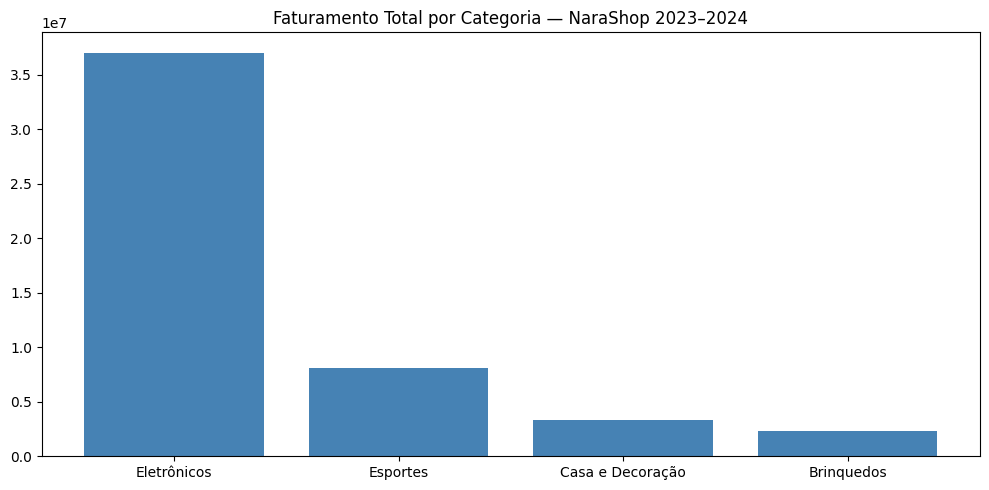

In [29]:
# Fluxo já conhecido — Aula 02


fat_cat = df.groupby('categoria')['valor_pedido'].sum().reset_index()
fat_cat = fat_cat.sort_values(by='valor_pedido', ascending=False)
# Só adicionamos estas linhas
plt.figure(figsize=(10, 5))
plt.bar(fat_cat['categoria'], fat_cat['valor_pedido'], color='steelblue')
plt.title('Faturamento Total por Categoria — NaraShop 2023–2024')
plt.tight_layout() 
plt.show()


In [34]:
# Carregar dados arquivos baixados de cada semestre os arquivos CSV
df_2024_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
df_2024_2 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
df_2025_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
df_2025_2 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
#df_2024_1.head()

df_gas = pd.concat([df_2024_1, df_2024_2,df_2025_1,df_2025_2],ignore_index=True)
print(df_gas.shape) 
display(df_gas.head())

(1908616, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


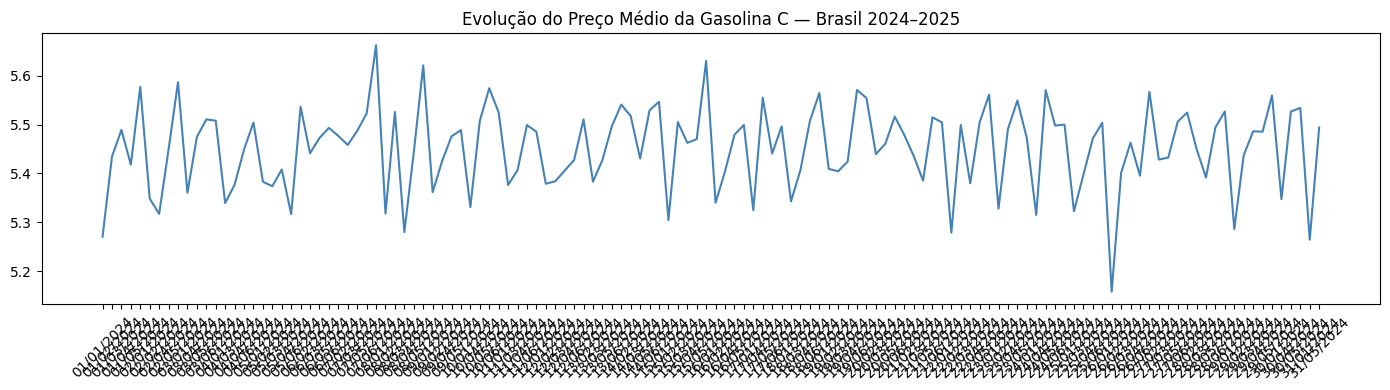

In [35]:
#Preco medio da Gasolina C por semana — ANP 2024-2025
preco_tempo = df_gas.groupby('Data da Coleta')['Valor de Venda'].mean()
plt.figure(figsize=(14, 4)) 
plt.plot(preco_tempo.index, preco_tempo.values, color='steelblue')
plt.title('Evolução do Preço Médio da Gasolina C — Brasil 2024–2025') 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()